# S2 | Answer Distribution — Yes/No & Number

Recovered from session 1 `A2_mmstar.ipynb` (commit `2bbcec7`), adapted to S2 data.

Shows **normalized horizontal stacked bar charts** for each model group:
- **Ground Truth** — VQA majority answer (`multiple_choice_answer`)
- **Humans** — S2 study participants, variant C (original question)
- **VLM** — full vision-language model (blind PNG passed)
- **VLM decoder** — VLM weights, vision encoder bypassed
- **Standalone LLM** — pure text LLM, nothink mode
- **Standalone LLM (think)** — pure text LLM, think mode (Qwen3 only)

**Section 1 — Blind condition**
**Section 2 — Inst-blind condition**

Two plots per section: yes/no distribution and number distribution.

In [ ]:
import json
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '/home/david/Desktop/yuna/HPA/analysis')
from utils.vqa import VQAAnswerMapper, extract_number, bin_number

mapper = VQAAnswerMapper()
mapper._load()

BASE = '/home/david/Desktop/yuna/HPA'
EXPORTS = os.path.join(BASE, 'analysis/session2/exports')

SOURCE_ORDER = [
    'Ground Truth', 'Humans',
    'VLM', 'VLM decoder', 'Standalone LLM', 'Standalone LLM (think)',
]

MODEL_GROUP_RENAME = {
    'VLM': 'VLM',
    'VLM backbone decoder': 'VLM decoder',
    'standalone LLM': 'Standalone LLM',
    'standalone LLM (think)': 'Standalone LLM (think)',
}

print('Setup complete.')


   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
Setup complete.


In [65]:
# ── Build answer_type lookup from VQA annotations ────────────────────────────
qid2atype = {
    int(qid): ann.get('answer_type', 'other')
    for qid, ann in mapper.annotations.items()
}
qid2gt = {
    int(qid): ann.get('multiple_choice_answer', '')
    for qid, ann in mapper.annotations.items()
}
print(f'Answer types: {pd.Series(qid2atype.values()).value_counts().to_dict()}')


Answer types: {'other': 105679, 'yes/no': 80541, 'number': 28134}


In [ ]:
# ── Load model outputs from canonical exports ────────────────────────────────
# These exports already use the shared preprocessing pipeline used elsewhere in S2.
# They retain variant labels and model-group assignments, so they are safer than
# the older raw-jsonl notebook loader.

blind_df = pd.read_csv(os.path.join(EXPORTS, 'responses_model_blind.csv'))
inst_df  = pd.read_csv(os.path.join(EXPORTS, 'responses_model_inst_blind.csv'))

model_rows = []
for cond, df_ in [('blind', blind_df), ('inst_blind', inst_df)]:
    sub = df_[df_['variant'] == 'C'].copy()
    sub['source'] = sub['model_group'].map(MODEL_GROUP_RENAME)
    sub['condition'] = cond
    sub['qid'] = sub['question_id'].astype(int)
    sub['output'] = sub['response'].fillna('').astype(str).str.strip().str.lower()
    sub['answer_type'] = sub['qid'].map(qid2atype)
    model_rows.append(sub[['qid', 'answer_type', 'source', 'model', 'condition', 'output']])

model_df = pd.concat(model_rows, ignore_index=True)
print(f'Model rows: {len(model_df)}')
print(model_df.groupby(['source', 'condition']).size().unstack(fill_value=0))

In [ ]:
# ── Load human answers from canonical export (variant C, inst_blind) ─────────
human_src = pd.read_csv(os.path.join(EXPORTS, 'responses_human.csv'))
human_sub = human_src[human_src['variant'] == 'C'].copy()
human_df = pd.DataFrame({
    'qid': human_sub['question_id'].astype(int),
    'answer_type': human_sub['question_id'].astype(int).map(qid2atype),
    'source': 'Humans',
    'output': human_sub['response'].fillna('').astype(str).str.strip().str.lower(),
})
print(f'Human rows: {len(human_df)} from {human_sub["participant"].nunique()} participants')
print(human_df.groupby('answer_type').size())

In [68]:
# ── Build GT rows + combine ───────────────────────────────────────────────────
all_qids = set(model_df['qid'].unique()) | set(human_df['qid'].unique())

gt_rows = []
for qid in all_qids:
    gt_rows.append({
        'qid':         qid,
        'answer_type': qid2atype.get(qid, 'other'),
        'source':      'Ground Truth',
        'condition':   'both',
        'output':      str(qid2gt.get(qid, '')).strip().lower(),
    })

gt_df = pd.DataFrame(gt_rows)
human_df['condition'] = 'inst_blind'
all_df = pd.concat([gt_df, human_df, model_df], ignore_index=True)
print(f'Total rows: {len(all_df)}')
print(all_df.groupby(['source', 'condition']).size().unstack(fill_value=0))


Total rows: 71339
condition               blind  both  inst_blind
source                                         
Ground Truth                0  1000           0
Humans                      0     0        5112
Standalone LLM           8000     0        8000
Standalone LLM (think)   4227     0        5000
VLM                     10000     0       10000
VLM decoder             10000     0       10000


In [69]:
# ── Shared plot helpers ───────────────────────────────────────────────────────
# All outputs already passed through preprocess_answer() (think-stripped, punctuation
# normalized, digit/article normalized) — same pipeline as vqa_accuracy scoring.

def classify_yn(s):
    s = str(s).strip()
    if s == 'yes' or s.startswith('yes '):  return 'yes'
    if s == 'no'  or s.startswith('no '):   return 'no'
    return 'others'

def make_yn_stack(df, condition):
    """Return normalized pivot for yes/no questions under a given condition."""
    sub = df[(df['answer_type'] == 'yes/no')].copy()
    mask_model = ~sub['source'].isin(['Ground Truth', 'Humans'])
    sub = sub[~mask_model | (sub['condition'] == condition)]

    sub['y/n'] = sub['output'].apply(classify_yn)
    sub['source'] = pd.Categorical(sub['source'], categories=SOURCE_ORDER, ordered=True)

    counts = sub.value_counts(['source', 'y/n']).reset_index(name='count')
    counts['proportion'] = counts.groupby('source')['count'].transform(lambda x: x / x.sum())
    stack = counts.pivot(index='source', columns='y/n', values='proportion').fillna(0)
    return stack.reindex(SOURCE_ORDER).dropna(how='all')

def make_num_stack(df, condition):
    """Return normalized pivot for number questions under a given condition."""
    sub = df[(df['answer_type'] == 'number')].copy()
    mask_model = ~sub['source'].isin(['Ground Truth', 'Humans'])
    sub = sub[~mask_model | (sub['condition'] == condition)]

    sub['number_bin'] = sub['output'].apply(
        lambda x: bin_number(extract_number(x)) if extract_number(x) is not None else 'others'
    )
    sub['source'] = pd.Categorical(sub['source'], categories=SOURCE_ORDER, ordered=True)

    counts = sub.value_counts(['source', 'number_bin']).reset_index(name='count')
    counts['proportion'] = counts.groupby('source')['count'].transform(lambda x: x / x.sum())
    stack = counts.pivot(index='source', columns='number_bin', values='proportion').fillna(0)
    return stack.reindex(SOURCE_ORDER).dropna(how='all')

def plot_yn(stack_df, title=''):
    colors = {'yes': '#6BA292', 'no': '#C97A6A', 'others': '#B5B5B5'}
    cats   = [c for c in ['yes', 'no', 'others'] if c in stack_df.columns]
    n_rows = stack_df.shape[0]

    fig, ax = plt.subplots(figsize=(7, 0.8 * n_rows + 1.4))
    stack_df[cats].plot(kind='barh', stacked=True, ax=ax,
                        color=[colors[c] for c in cats], width=0.75)
    ax.invert_yaxis()
    ax.set_xlim(0, 1)
    ax.set_ylabel('')
    ax.grid(False)
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    for i, src in enumerate(stack_df.index):
        cum = 0
        for cat in cats:
            val = stack_df.loc[src, cat]
            if val > 0.04:
                ax.text(cum + val / 2, i, f'{val*100:.0f}%',
                        ha='center', va='center', color='white', fontsize=10, fontweight='bold')
            cum += val
    ax.legend(loc='lower right', bbox_to_anchor=(0.72, -0.12), ncol=3, frameon=False)
    if title:
        ax.set_title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_num(stack_df, title=''):
    colors = {
        '0': '#DADADA', '1': '#BFD7EA', '2\u20133': '#9EC1A3',
        '4\u20135': '#7FB3A2', '6\u201310': '#5C8D89',
        '11\u201320': '#4C6A92', '>20': '#8E5A5A', 'others': '#B5B5B5'
    }
    ORDER = ['0','1','2\u20133','4\u20135','6\u201310','11\u201320','>20','others']
    ORDER = [o for o in ORDER if o in stack_df.columns]
    n_rows = stack_df.shape[0]

    fig, ax = plt.subplots(figsize=(11, 0.8 * n_rows + 1.4))
    stack_df[ORDER].plot(kind='barh', stacked=True, ax=ax,
                         color=[colors[c] for c in ORDER], width=0.75)
    ax.invert_yaxis()
    ax.set_xlim(0, 1)
    ax.set_ylabel('')
    ax.grid(False)
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    for i, src in enumerate(stack_df.index):
        cum = 0
        for cat in ORDER:
            val = stack_df.loc[src, cat] if cat in stack_df.columns else 0
            if val > 0.04:
                ax.text(cum + val / 2, i, f'{val*100:.0f}%',
                        ha='center', va='center', color='white', fontsize=10, fontweight='bold')
            cum += val
    ax.tick_params(axis='y', labelsize=11)
    ax.legend(bbox_to_anchor=(0.5, -0.08), loc='upper center',
              ncol=len(ORDER), frameon=False, fontsize=10)
    if title:
        ax.set_title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

print('Plot helpers defined.')

Plot helpers defined.


## Section 1 — Blind Condition

In [70]:
# ── Inspect Standalone LLM "others" answers ───────────────────────────────────
# Shows top output strings and raw samples to diagnose why they land in "others"

llm_blind = model_df[
    (model_df['source'] == 'Standalone LLM') &
    (model_df['condition'] == 'blind')
].copy()

for atype, classify_fn in [
    ('yes/no',  lambda x: classify_yn(x)),
    ('number',  lambda x: 'number' if extract_number(x) is not None else 'others'),
]:
    sub = llm_blind[llm_blind['answer_type'] == atype].copy()
    sub['class'] = sub['output'].apply(classify_fn)
    others = sub[sub['class'] == 'others']

    print(f'\n{"="*60}')
    print(f'  answer_type = {atype}  |  total={len(sub)}  others={len(others)} ({len(others)/len(sub)*100:.0f}%)')
    print(f'{"="*60}')

    # Top outputs overall
    print('\n── Top 20 output strings (all classes) ──')
    print(sub['output'].value_counts().head(20).to_string())

    # Per-model "others" rate
    print('\n── "others" rate per model ──')
    per_model = sub.groupby('model')['class'].apply(
        lambda x: (x == 'others').mean()
    ).sort_values(ascending=False)
    print(per_model.round(3).to_string())

    # Sample 10 "others" outputs with their question
    print('\n── Sample "others" outputs (blind, variant C) ──')
    sample = others.sample(min(10, len(others)), random_state=42)[['model', 'qid', 'output']]
    qid2q = {}
    for _, r in sample.iterrows():
        ann = mapper.annotations.get(int(r['qid']), {})
        qid2q[r['qid']] = ann.get('question', '?')
    sample = sample.copy()
    sample['question'] = sample['qid'].map(qid2q)
    sample['output_preview'] = sample['output'].str[:80]
    print(sample[['model', 'question', 'output_preview']].to_string(index=False))


  answer_type = yes/no  |  total=3104  others=1771 (57%)

── Top 20 output strings (all classes) ──
output
yes                                                      911
                                                         681
no                                                       284
possibly                                                  43
i cannot determine that based on given information        15
unknown                                                   14
clear                                                     13
sun                                                       10
cloudy                                                     7
on                                                         7
photo                                                      6
clean                                                      6
calm                                                       6
water                                                      6
real                                  

                   model question                                                                   output_preview
          vicuna-7b-v1.5        ?                                                                                 
              Qwen3-0.6B        ?                                                                             flip
              Qwen3-1.7B        ?                                                               i see street light
          vicuna-7b-v1.5        ?                                                                                 
              Qwen3-1.7B        ? to determine if there is runner on third we would need to know current state of 
Mistral-7B-Instruct-v0.2        ?                                          maybe without more context it's unclear
Mistral-7B-Instruct-v0.2        ? smiling or delighted if girl is indeed enjoying her food and it's visible from h
              Qwen3-0.6B        ?                                               

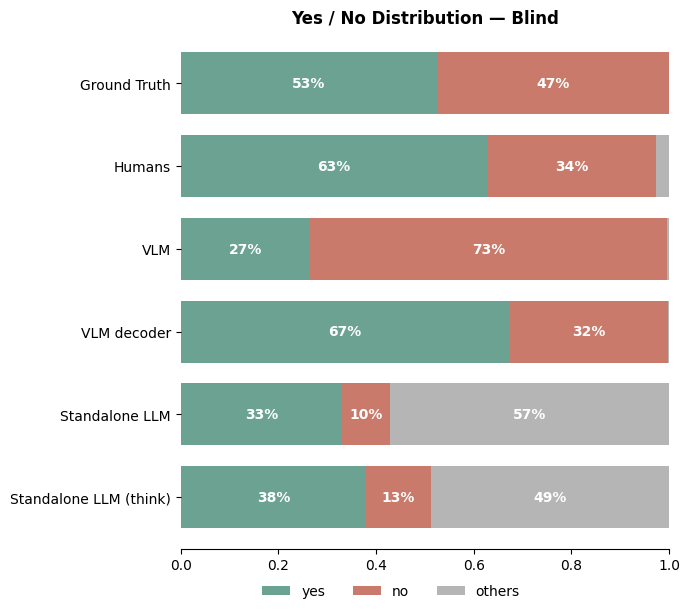

In [71]:
plot_yn(make_yn_stack(all_df, 'blind'), title='Yes / No Distribution — Blind')

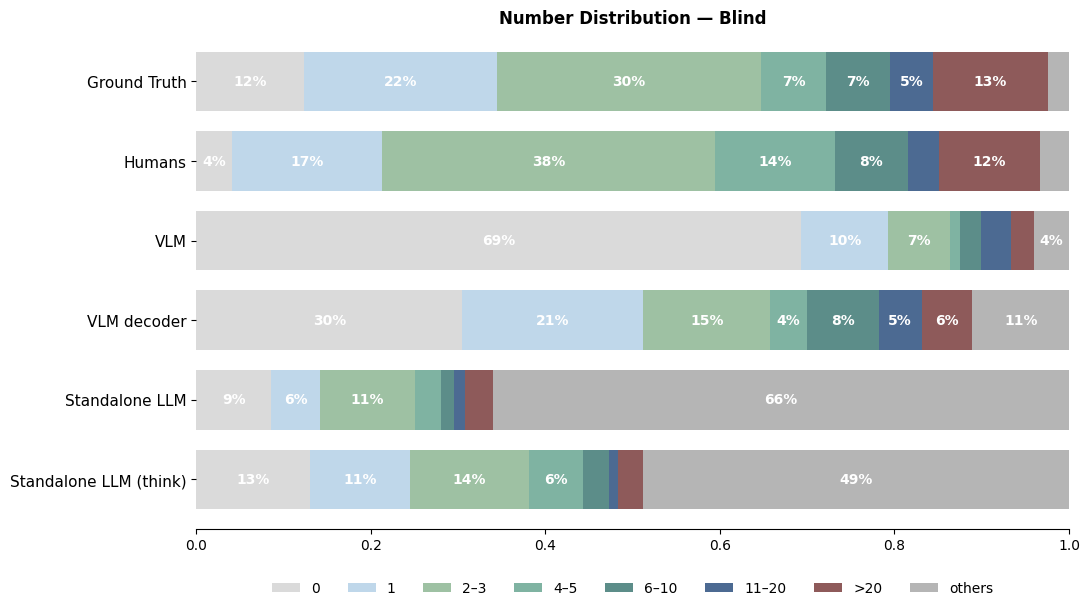

In [72]:
plot_num(make_num_stack(all_df, 'blind'), title='Number Distribution — Blind')

## Section 2 — Inst-Blind Condition

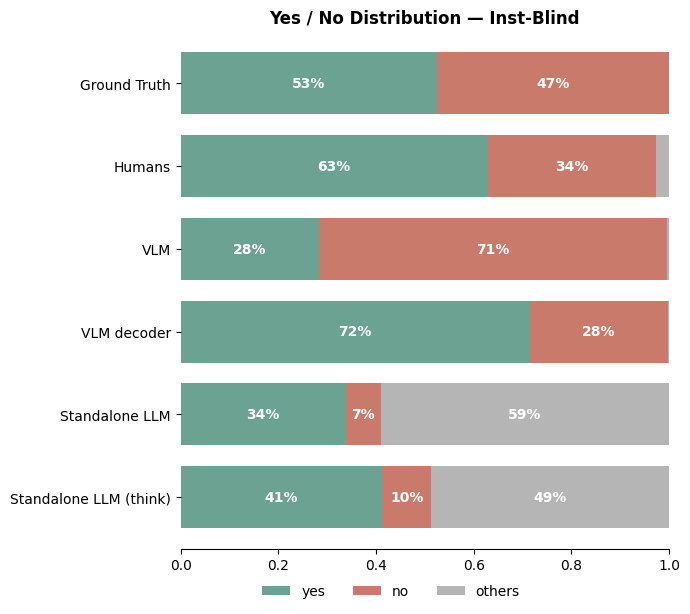

In [73]:
plot_yn(make_yn_stack(all_df, 'inst_blind'), title='Yes / No Distribution — Inst-Blind')

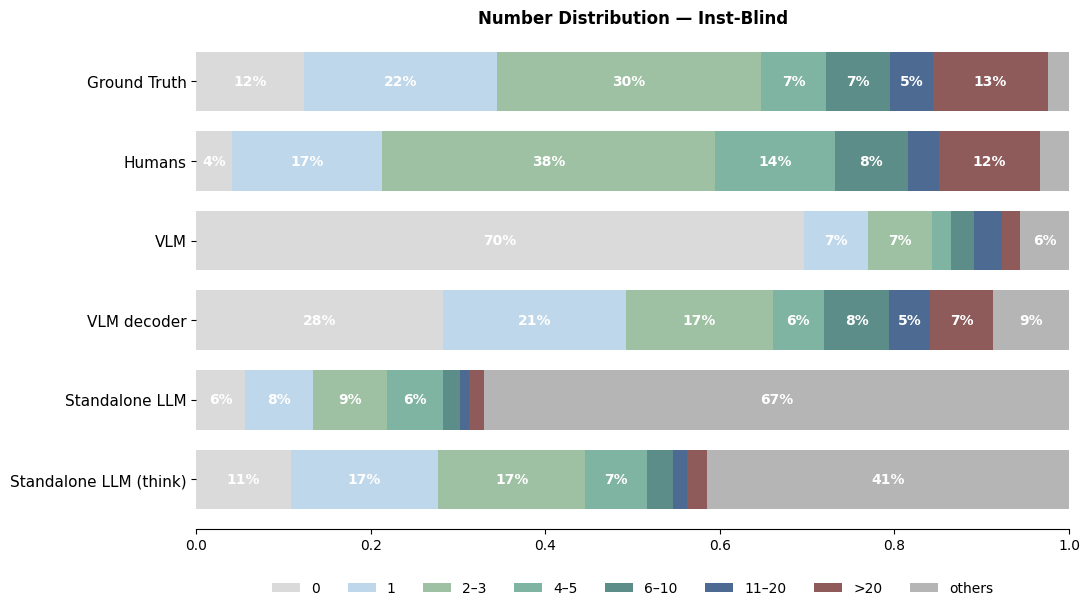

In [74]:
plot_num(make_num_stack(all_df, 'inst_blind'), title='Number Distribution — Inst-Blind')